# EDA 06 — Intervalos de confianza con diseño muestral

**Objetivo:** incorporar estratos, UPM y `fexp` para cuantificar la precisión de las tasas y de cuatro contrastes primarios.

La tasa de cada grupo es una razón de totales ponderados. Su varianza se estima mediante linealización de Taylor, agregando influencias por UPM y centrándolas dentro de estratos. Se conservan las 334 786 filas para que una UPM sin casos del dominio aporte cero en lugar de desaparecer.

Los intervalos de tasas usan escala logit; los de diferencias, escala lineal y distribución t con 7 630 grados de libertad. Los cuatro valores p primarios se ajustan con Holm.

In [1]:
# ETAPA 6 / ARCHIVO: cuaderno 06 / BLOQUE 1: localizar resultados verificados.
from pathlib import Path  # Representa carpetas y archivos.
import json  # Lee resúmenes estructurados.
import pandas as pd  # Trabaja con tablas.
from IPython.display import SVG, display  # Presenta tablas y figuras vectoriales.
RAIZ = Path.cwd() if (Path.cwd() / 'reports/eda06_inferencia').exists() else Path.cwd().parent  # Admite iniciar en proyecto o notebooks.
REPORTES = RAIZ / 'reports/eda06_inferencia'  # Localiza tablas inferenciales.
FIGURAS = RAIZ / 'reports/figures/eda06_inferencia'  # Localiza gráficos.
resumen = json.loads((REPORTES / '00_resumen_inferencia.json').read_text(encoding='utf-8'))  # Recupera resultados centrales.
verificacion = json.loads((REPORTES / '05_verificacion_inferencia.json').read_text(encoding='utf-8'))  # Recupera controles del cálculo.
assert verificacion['estado'] == 'verificado'  # Exige una ejecución válida.
assert verificacion['prueba_predictiva_evaluada'] is False  # Confirma la separación de la prueba de modelos.
display(pd.Series(resumen, name='valor').to_frame())  # Presenta el resumen.

,valor
estado,completado
metodo,"linealización de Taylor, aproximación con reem..."
grados_libertad,7630
t_critico_95,1.960275
tasa_total,68.853455
ic95_total,"[67.54418664309729, 70.13326108958763]"
brecha_mujeres_hombres_pp,-5.909736
ic95_mujeres_hombres,"[-8.013330833912445, -3.806141455633362]"
p_holm_mujeres_hombres,0.0
brecha_rural_urbana_pp,-10.973926


## 1. Tasa total y precisión

La tasa total es 68,85 % (IC 95 %: 67,54–70,13). El error estándar es 0,66 puntos porcentuales. El intervalo representa incertidumbre del diseño bajo las decisiones declaradas; no cubre errores de medición o clasificación.

In [2]:
# BLOQUE 2: consultar la estimación total.
tasas = pd.read_csv(REPORTES / '01_tasas_con_ic95.csv', dtype={'codigo': 'string'})  # Lee las 47 estimaciones.
total = tasas.loc[tasas['variable'] == 'total']  # Selecciona el dominio completo.
display(total[['etiqueta', 'n', 'upm_con_casos', 'porcentaje', 'error_estandar_pp', 'ic95_inferior', 'ic95_superior', 'cv_porcentaje']])  # Presenta punto y precisión.

,etiqueta,n,upm_con_casos,porcentaje,error_estandar_pp,ic95_inferior,ic95_superior,cv_porcentaje
0,Total del dominio,39551,6326,68.853455,0.660501,67.544187,70.133261,0.959285


## 2. Sexo y área

La diferencia mujeres menos hombres es −5,91 puntos porcentuales (−8,01 a −3,81). La diferencia rural menos urbana es −10,97 puntos (−14,90 a −7,05). Ambas permanecen por debajo de cero después de considerar el diseño y sus valores p de Holm son menores que 0,001.

Esto respalda diferencias observadas, no efectos causales. Todavía falta el ajuste simultáneo mediante regresión.

,grupo_a,grupo_b,diferencia_pp,error_estandar_pp,ic95_inferior,ic95_superior,valor_p_holm,significativo_holm_005
0,Mujer,Hombre,-5.909736,1.073112,-8.013331,-3.806141,1.129979e-07,True
1,Rural,Urbana,-10.973926,2.003961,-14.902241,-7.045611,1.129979e-07,True
2,Superior no universitario,Superior Universitario,-2.371280,1.552754,-5.415105,0.672546,1.267666e-01,False
3,Post-grado,Superior Universitario,19.305507,1.255804,16.843785,21.767229,6.058980e-52,True


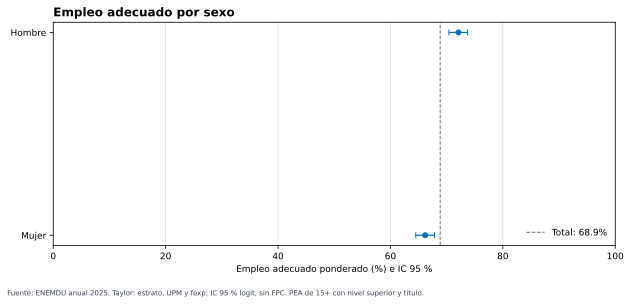

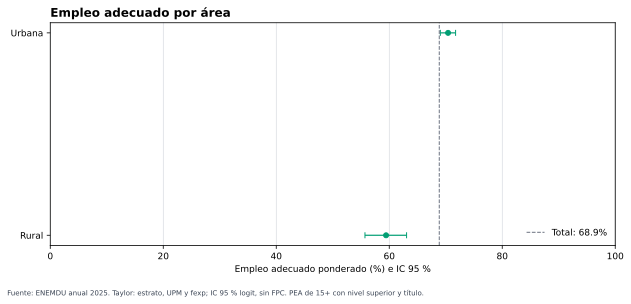

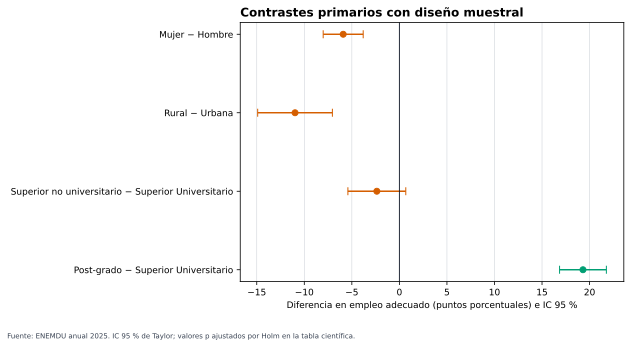

In [3]:
# BLOQUE 3: revisar sexo, área y contrastes.
contrastes = pd.read_csv(REPORTES / '02_contrastes_primarios_ic95.csv')  # Lee las cuatro comparaciones preespecificadas.
display(contrastes[['grupo_a', 'grupo_b', 'diferencia_pp', 'error_estandar_pp', 'ic95_inferior', 'ic95_superior', 'valor_p_holm', 'significativo_holm_005']])  # Presenta magnitud, precisión y evidencia.
display(SVG(filename=str(FIGURAS / '01_ic_sexo.svg')))  # Presenta tasas por sexo.
display(SVG(filename=str(FIGURAS / '02_ic_area.svg')))  # Presenta tasas por área.
display(SVG(filename=str(FIGURAS / '06_ic_contrastes_primarios.svg')))  # Presenta diferencias frente a cero.

## 3. Educación

Superior no universitaria menos universitaria es −2,37 puntos (−5,42 a 0,67; p de Holm=0,127). El intervalo incluye cero. Posgrado menos universitaria es +19,31 puntos (16,84 a 21,77; p de Holm<0,001). La diferencia observada puede estar confundida por otras características.

,etiqueta,n,porcentaje,error_estandar_pp,ic95_inferior,ic95_superior,cv_porcentaje
20,Post-grado,7262,85.584374,1.038693,83.426417,87.503443,1.213647
21,Superior no universitario,6425,63.907587,1.377129,61.166548,66.560922,2.154876
22,Superior Universitario,25864,66.278867,0.804395,64.684379,67.837160,1.213653


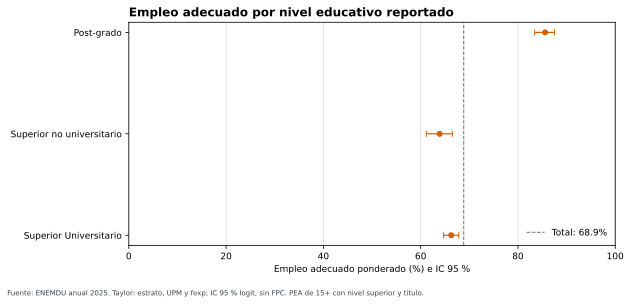

In [4]:
# BLOQUE 4: revisar tasas educativas e intervalos.
educacion = tasas.loc[tasas['variable'] == 'p10a']  # Selecciona nivel reportado.
display(educacion[['etiqueta', 'n', 'porcentaje', 'error_estandar_pp', 'ic95_inferior', 'ic95_superior', 'cv_porcentaje']])  # Presenta precisión educativa.
display(SVG(filename=str(FIGURAS / '04_ic_educacion.svg')))  # Presenta el gráfico educativo.

## 4. Edad y grupos pequeños

La prueba global detecta heterogeneidad por edad. Las categorías de 15–19, 80–84 y 85–89 tienen menos de 100 registros. Sus intervalos son amplios y los CV alcanzan valores muy altos. Antes de publicar comparaciones por edad se deberá justificar una agrupación más estable.

,etiqueta,n,porcentaje,ic95_inferior,ic95_superior,cv_porcentaje,alerta_n_menor_100
5,15–19,11,2.998300,0.353052,21.238757,107.186172,True
6,20–24,2411,40.628429,36.505072,44.888270,5.274890,False
7,25–29,6783,57.551548,54.522994,60.524440,2.662940,False
8,30–34,6577,68.966154,65.831558,71.935774,2.259780,False
9,35–39,5290,77.040478,74.026552,79.800105,1.912039,False
10,40–44,4769,76.635554,73.941642,79.129577,1.727154,False
11,45–49,3935,78.745222,74.963971,82.091809,2.308902,False
12,50–54,3600,77.453605,74.006562,80.563582,2.159944,False
13,55–59,2891,78.401608,74.305283,82.003056,2.504720,False
14,60–64,1875,68.786900,63.738987,73.425079,3.600502,False


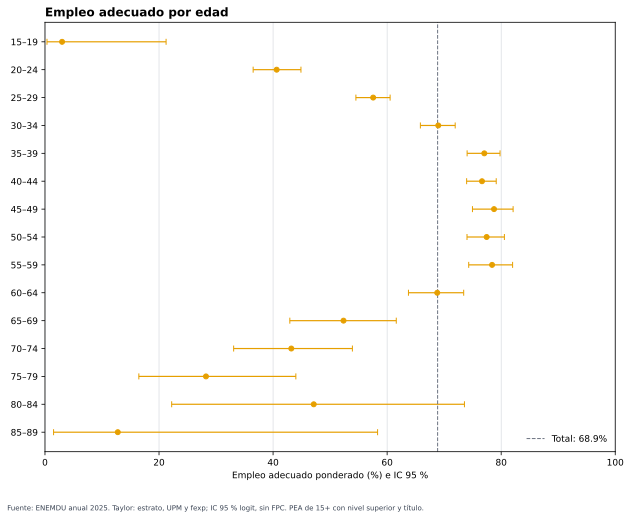

In [5]:
# BLOQUE 5: revisar edad y alertas de tamaño.
edad = tasas.loc[tasas['variable'] == 'grupo_edad']  # Selecciona grupos etarios.
display(edad[['etiqueta', 'n', 'porcentaje', 'ic95_inferior', 'ic95_superior', 'cv_porcentaje', 'alerta_n_menor_100']])  # Hace visibles las alertas.
display(SVG(filename=str(FIGURAS / '03_ic_edad.svg')))  # Presenta puntos e intervalos.

## 5. Provincia

Existe heterogeneidad global entre provincias, pero los intervalos tienen amplitudes diferentes y muchas estimaciones se superponen. Morona Santiago tiene el punto más alto, 89,66 %, con IC 71,52–96,77; su intervalo impide tratar la posición como un rango exacto. No se hicieron comparaciones entre todos los pares.

,etiqueta,n,upm_con_casos,porcentaje,error_estandar_pp,ic95_inferior,ic95_superior,cv_porcentaje
43,Chimborazo,778,110,48.077015,2.616861,42.985273,53.209016,5.443061
42,Cotopaxi,880,124,55.376186,3.193957,49.062891,61.520686,5.767746
26,Los Ríos,389,88,60.133473,5.522934,48.985664,70.321155,9.184459
25,Loja,1197,203,62.367181,2.603354,57.143999,67.317856,4.174237
32,Tungurahua,5217,623,62.447714,1.870832,58.715316,66.037858,2.995838
24,Imbabura,1477,266,62.634335,1.981636,58.675857,66.430566,3.163817
45,Esmeraldas,1510,297,64.426267,2.063712,60.286142,68.361297,3.203216
30,Pastaza,826,128,64.729548,4.264100,55.997141,72.577645,6.587564
41,Carchi,683,135,64.920066,3.452779,57.891672,71.355785,5.318508
29,Napo,560,98,65.368244,4.616135,55.861601,73.788099,7.061739


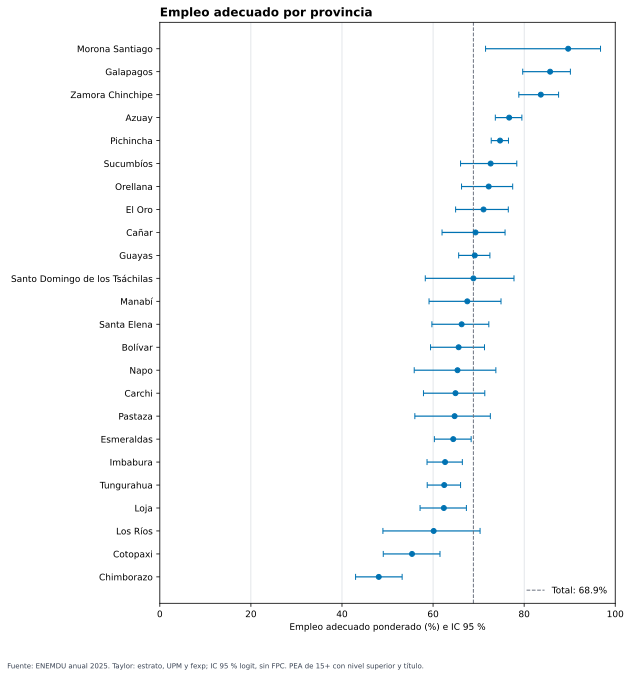

In [6]:
# BLOQUE 6: revisar tasas provinciales con precisión.
provincia = tasas.loc[tasas['variable'] == 'prov'].sort_values('porcentaje')  # Ordena puntos para lectura.
display(provincia[['etiqueta', 'n', 'upm_con_casos', 'porcentaje', 'error_estandar_pp', 'ic95_inferior', 'ic95_superior', 'cv_porcentaje']])  # Presenta soporte e incertidumbre.
display(SVG(filename=str(FIGURAS / '05_ic_provincia.svg')))  # Presenta el perfil territorial.

## 6. Pruebas globales

Una prueba global evalúa si todas las categorías podrían compartir la misma tasa. Sexo, área, edad, educación y provincia presentan evidencia global al 5 %. La prueba no identifica por sí sola qué pares difieren; para eso se necesitan contrastes definidos y control de multiplicidad.

In [7]:
# BLOQUE 7: consultar pruebas globales de Wald.
globales = pd.read_csv(REPORTES / '03_pruebas_globales_wald.csv')  # Lee las cinco pruebas.
display(globales)  # Presenta grados de libertad, estadístico y valor p.
assert globales['evidencia_global_005'].all()  # Confirma el resultado registrado.

,variable,categorias,grados_libertad_prueba,estadistico_wald,valor_p,evidencia_global_005,referencia_computacional
0,p02,2,1,30.328158,3.647917e-08,True,Hombre
1,area,2,1,29.987858,4.347601e-08,True,Urbana
2,grupo_edad,15,14,884.810488,7.750853e-180,True,15–19
3,p10a,3,2,282.112816,5.495160e-62,True,Post-grado
4,prov,24,23,278.848983,8.365290e-46,True,Azuay


## 7. Tabla científica y siguiente etapa

La tabla científica combina estimación, error estándar, IC, CV, n, UPM, estratos y grados de libertad. El Excel incluye hojas de resumen, detalle, contrastes, pruebas globales y método.

La hipótesis de diferencias descriptivas queda evaluada. La hipótesis ajustada requiere regresión logística. La comparación entre regresión y árboles requiere desarrollar modelos con los cinco pliegues internos, congelar las decisiones y usar la prueba una sola vez.

**Ejercicio:** compara el punto y el intervalo de Morona Santiago con Pichincha. Explica por qué el punto mayor no basta para afirmar que la tasa poblacional sea mayor.